In [1]:
%pip install tensorflow numpy pandas scikit-learn matplotlib pillow


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import random
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(tf.__version__)

2.21.0


In [4]:
BASE_DIR = '.'

IMG_DIR = os.path.join(BASE_DIR, 'img')

TRAIN_LABEL = pd.read_csv(
    os.path.join(BASE_DIR, 'train-label.csv'),
    index_col='id'
)

TEST_LABEL = pd.read_csv(
    os.path.join(BASE_DIR, 'test-label.csv'),
    index_col='id'
)

print(TRAIN_LABEL.head())
print(TEST_LABEL.head())

                                    file  label
id                                             
0   001bd5563b4511f0b16c00155d672fff.png      1
1   d13cde743b4411f0b16c00155d672fff.jpg      0
2   96f4bf1a3b4511f0b16c00155d672fff.jpg      1
3   43f18faa3b4511f0b16c00155d672fff.jpg      0
4   bf0df3a03b4411f0b16c00155d672fff.png      1
                                      file  label
id                                               
2078  082a7a903b4511f0b16c00155d672fff.jpg     -1
2079  0f9948383b4511f0b16c00155d672fff.png     -1
2080  eb1ae4b23b4411f0b16c00155d672fff.jpg     -1
2081  82f265443b4511f0b16c00155d672fff.jpg     -1
2082  ca5236363b4411f0b16c00155d672fff.jpg     -1


In [5]:
IMG_SIZE = 224

BATCH_SIZE = 16

EPOCHS = 60

LR = 1e-3

WEIGHT_DECAY = 1e-4

DROPOUT = 0.35

VAL_SPLIT = 0.15

In [6]:
def resize_with_padding(img, target_size=224):

    w, h = img.size

    scale = target_size / max(w, h)

    nw = int(w * scale)
    nh = int(h * scale)

    img = img.resize((nw, nh), Image.BILINEAR)

    canvas = Image.new('RGB', (target_size, target_size), (0, 0, 0))

    paste_x = (target_size - nw) // 2
    paste_y = (target_size - nh) // 2

    canvas.paste(img, (paste_x, paste_y))

    return canvas


def load_image(filepath):

    img = Image.open(filepath).convert('RGB')

    img = resize_with_padding(img, IMG_SIZE)

    img = np.array(img, dtype=np.float32) / 255.0

    return img

In [7]:
def load_dataset(df, img_dir, has_labels=True):

    images = []
    labels = []

    missing = 0

    for _, row in df.iterrows():

        path = os.path.join(img_dir, row['file'])

        if not os.path.exists(path):
            missing += 1
            continue

        img = load_image(path)

        images.append(img)

        if has_labels:
            labels.append(int(row['label']))

    X = np.array(images, dtype=np.float32)

    y = np.array(labels, dtype=np.int32) if has_labels else None

    print("Missing:", missing)

    return X, y

In [8]:
print("Loading train data...")
X_all, y_all = load_dataset(TRAIN_LABEL, IMG_DIR, True)

print("Loading test data...")
X_test, _ = load_dataset(TEST_LABEL, IMG_DIR, False)

print(X_all.shape)
print(X_test.shape)

Loading train data...
Missing: 0
Loading test data...
Missing: 0
(1385, 224, 224, 3)
(1386, 224, 224, 3)


In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X_all,
    y_all,
    test_size=VAL_SPLIT,
    stratify=y_all,
    random_state=SEED
)

print(X_train.shape)
print(X_val.shape)

(1177, 224, 224, 3)
(208, 224, 224, 3)


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

def augment(image, label):

    image = tf.image.random_flip_left_right(image)

    image = tf.image.random_flip_up_down(image)

    image = tf.image.random_brightness(image, 0.2)

    image = tf.image.random_contrast(image, 0.8, 1.2)

    image = tf.image.random_saturation(image, 0.8, 1.2)

    image = tf.image.random_hue(image, 0.05)

    # random jpeg quality
    image = tf.image.random_jpeg_quality(
        tf.cast(image * 255, tf.uint8),
        70,
        100
    )

    image = tf.cast(image, tf.float32) / 255.0

    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, label

In [11]:
train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train), seed=SEED)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset
    .from_tensor_slices(X_test)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Datasets ready")

Datasets ready


In [12]:
def residual_block(x, filters, stride=1):

    shortcut = x

    x = layers.Conv2D(
        filters,
        3,
        strides=stride,
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(WEIGHT_DECAY)
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Activation(tf.nn.gelu)(x)

    x = layers.Conv2D(
        filters,
        3,
        padding='same',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(WEIGHT_DECAY)
    )(x)

    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:

        shortcut = layers.Conv2D(
            filters,
            1,
            strides=stride,
            padding='same'
        )(shortcut)

        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])

    x = layers.Activation(tf.nn.gelu)(x)

    return x

In [13]:
def se_block(x, ratio=8):

    filters = x.shape[-1]

    se = layers.GlobalAveragePooling2D()(x)

    se = layers.Dense(filters // ratio, activation='relu')(se)

    se = layers.Dense(filters, activation='sigmoid')(se)

    se = layers.Reshape((1,1,filters))(se)

    x = layers.Multiply()([x, se])

    return x

In [14]:
def build_model():

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = layers.Conv2D(
        32,
        3,
        padding='same',
        kernel_initializer='he_normal'
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = layers.Activation(tf.nn.gelu)(x)

    # Residual stages
    x = residual_block(x, 32)
    x = residual_block(x, 32)

    x = residual_block(x, 64, stride=2)
    x = residual_block(x, 64)

    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)

    # SE Attention
    x = se_block(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        256,
        activation=tf.nn.gelu,
        kernel_regularizer=regularizers.l2(WEIGHT_DECAY)
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(DROPOUT)(x)

    outputs = layers.Dense(2, activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    return model


model = build_model()

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 224, 224,  │      9,248 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 224, 224,  │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 224, 224,  │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 224, 224,  │      9,248 │ activation_3[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ batch_normalizat

 Total params: 2,886,242 (11.01 MB)

 Trainable params: 2,880,930 (10.99 MB)

 Non-trainable params: 5,312 (20.75 KB)

In [16]:
steps_per_epoch = len(X_train) // BATCH_SIZE

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR,
    decay_steps=steps_per_epoch * EPOCHS
)

optimizer = keras.optimizers.Adam(
    learning_rate=lr_schedule
)

loss_fn = keras.losses.SparseCategoricalCrossentropy()

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

print("Compiled")

Compiled


In [17]:
callbacks = [

    keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5554 - loss: 1.6106
Epoch 1: val_accuracy improved from None to 0.53365, saving model to best_model.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 357s 5s/step - accuracy: 0.5650 - loss: 1.3696 - val_accuracy: 0.5337 - val_loss: 22.4572
Epoch 2/60
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5666 - loss: 1.2699
Epoch 2: val_accuracy improved from 0.53365 to 0.64423, saving model to best_model.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 356s 5s/step - accuracy: 0.5641 - loss: 1.2421 - val_accuracy: 0.6442 - val_loss: 1.7264
Epoch 3/60
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5842 - loss: 1.1811
Epoch 3: val_accuracy did not improve from 0.64423
74/74 ━━━━━━━━━━━━━━━━━━━━ 350s 5s/step - accuracy: 0.5794 - loss: 1.2157 - val_accuracy: 0.5673 - val_loss: 6.9597
Epoch 4/60
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5685 - loss: 1.2355
Epoch 4: val_accuracy did not improve from 0.64423
74/74 ━━━━━━━━━━━━━━━━━━━━ 347s 5s/step - 

In [19]:
val_probs = model.predict(val_ds)

val_preds = np.argmax(val_probs, axis=1)

bal_acc = balanced_accuracy_score(y_val, val_preds)

print("Balanced Accuracy:", bal_acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 488ms/step
Balanced Accuracy: 0.7451905290418054


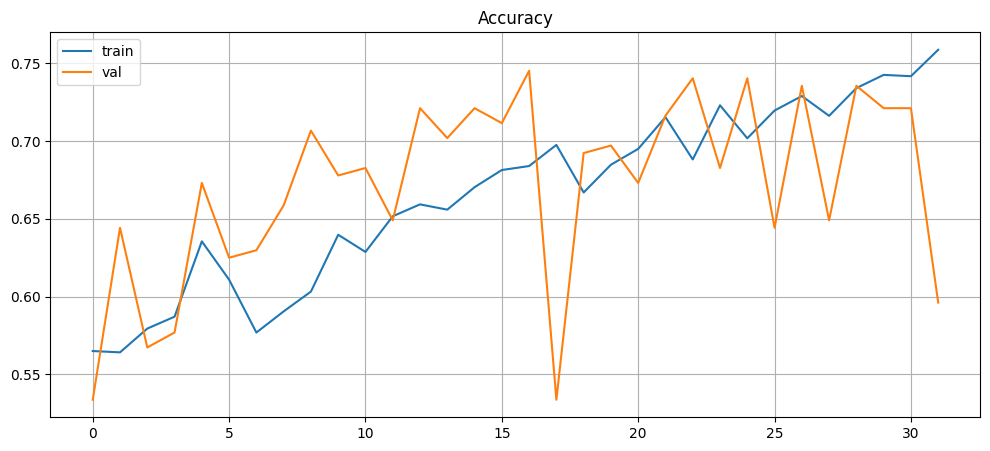

In [20]:
plt.figure(figsize=(12,5))

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')

plt.legend()

plt.title("Accuracy")

plt.grid(True)

plt.show()

In [21]:
def tta_predict(model, images):

    preds = []

    # original
    preds.append(model.predict(images, verbose=0))

    # horizontal flip
    flipped = tf.image.flip_left_right(images)

    preds.append(model.predict(flipped, verbose=0))

    # brightness
    brighter = tf.image.adjust_brightness(images, 0.05)

    preds.append(model.predict(brighter, verbose=0))

    final_pred = np.mean(preds, axis=0)

    return final_pred

In [22]:
test_probs = tta_predict(model, X_test)

test_preds = np.argmax(test_probs, axis=1)

print(test_preds.shape)

(1386,)


In [23]:
submission = pd.DataFrame({

    'id': TEST_LABEL.index,
    'label': test_preds
})

submission.to_csv(
    'submission5.csv',
    index=False
)

print(submission.head())

print("submission5.csv saved!")

     id  label
0  2078      1
1  2079      1
2  2080      0
3  2081      0
4  2082      1
submission5.csv saved!


In [24]:
check = pd.read_csv('submission5.csv')

print(check.head())

print(check.shape)

print(check['label'].value_counts())

assert set(check['label'].unique()).issubset({0,1})

assert len(check) == len(TEST_LABEL)

print("Submission verified!")

     id  label
0  2078      1
1  2079      1
2  2080      0
3  2081      0
4  2082      1
(1386, 2)
label
0    728
1    658
Name: count, dtype: int64
Submission verified!
